# Modèle intermédiaire - ArchPy & Modflow

In [1]:
import numpy as np
import matplotlib
from matplotlib import colors
import matplotlib.pyplot as plt
import geone
import geone.covModel as gcm
import geone.imgplot3d as imgplt3
import pyvista as pv
import flopy as fp
import sys
import os
from pathlib import Path
import math
import flopy.utils.binaryfile as bf
import flopy.discretization as fgrid
from flopy.utils.gridintersect import GridIntersect
from shapely.geometry import MultiLineString
import copy

archpy_path = "" #Set path to ArchPy
    
try:
    import ArchPy
except: # if ArchPy is not installed
    print("ArchPy not installed")
    sys.path.append(f"{archpy_path}")
    import ArchPy
#my modules
from ArchPy.base import *
from ArchPy.tpgs import *

ArchPy not installed


In [2]:
import geopandas as gpd
import flopy
from flopy.plot import PlotMapView

### Chargement du modèle

In [3]:
#load file
ws = '' #Path to the ArchPy model
#ws = "./../Modele_ArchPy_Noah 1/ArchPy_workspace"
modelname = "Versoix_model" #Name of the ArchPy model
T1 = import_project(modelname, ws=ws)

### IMPORTING PROJECT Versoix_BP_grid10_quick_alt IN C:/Users/Margaux/OneDrive - unine.ch/Documents/Unine/Master Thesis/3. Versoix model/ArchPy Model/ArchPy_workspace DIRECTORY ### 

Unit u12: Surface added for interpolation
Facies a added to unit u12
Facies b added to unit u12
Facies c added to unit u12
Facies d added to unit u12
Facies bc added to unit u12
Unit u14: Surface added for interpolation
Facies Molasse added to unit u14
Unit u3: Surface added for interpolation
Facies Soil added to unit u3
Facies a added to unit u3
Facies b added to unit u3
Facies c added to unit u3
Facies d added to unit u3
Facies e added to unit u3
Facies ab added to unit u3
Facies ac added to unit u3
Facies bc added to unit u3
Unit u7: Surface added for interpolation
Facies a added to unit u7
Facies b added to unit u7
Facies c added to unit u7
Facies d added to unit u7
Facies e added to unit u7
Facies ab added to unit u7
Facies bc added to unit u7
Unit u9: Surface added for interpolation
Facies a added to

In [4]:
import ArchPy.ap_mf
from ArchPy.ap_mf import archpy2modflow, array2cellids
import skimage
from skimage.measure import label

In [5]:
X0 = 2499498 #Model x0 coordinate 
Y0 = 1125350 #Model y0 coordinate 
X1 = 2502460 # 2'962 m
Y1 = 1128167 # 2'817 m

In [6]:
archpy_flow = archpy2modflow(T1, exe_name="Exe_mf6/mf6.exe")  # create the modflow model

# Simulation loop

In [7]:
iu_nb = 10
ifa_nb = 5

head_list = []

for iu in range(0,iu_nb): #iu=0 -> le modèle ne converge pas
    for ifa in range(ifa_nb):
        print('#####')
        print(f'Starting simulation iu = {iu}, ifa = {ifa}')
        print('#####')
        archpy_flow.create_sim(grid_mode="layers", iu=iu, unit_limit="u12")
        archpy_flow.set_k("K", iu=iu, ifa=ifa, ip=0, log=True, k_average_method="anisotropic")

        sim = archpy_flow.get_sim()
        gwf = archpy_flow.get_gwf()
        
        grid = gwf.modelgrid
        nrow = grid.nrow
        ncol = grid.ncol
        nlay = grid.nlay
        
        ix = GridIntersect(grid, method="vertex", rtree=True)
        
        idomain = grid.idomain

            # idomain cleaning --> remove isolated cells
    
        idomain = gwf.dis.idomain.array
    
        idomain_copy = idomain.copy() 
    
        labels, num = label(idomain_copy, return_num=True, connectivity=1, background=0)  # label va isoler chaque groupe indépendant
    
        c = 0  # petit compteur pour savoir combien de groupe ont été enlevé, pas indispensable
    
        for inum in range(num+1):
    
            mask = (labels == inum) 
    
            if np.sum(mask) < 300:  # on retire les groupes de cellules qui sont inférieurs à 300 (à modifier peut être mais chez moi cette valeur va bien)
    
                if (idomain[mask] == 1).any():
    
                    idomain[mask] = 0
    
                    c+= 1
        
        lst_active_cells = []
        for ilay in range(nlay):
            for irow in range(nrow):
                for icol in range(ncol):
                    if idomain[ilay, irow, icol] == 1:
                        lst_active_cells.append((ilay, irow, icol))
        
        riverDf = gpd.read_file(r'data_folder_versoix_sector\Versoix_river.shp')
        lakeDf = gpd.read_file(r'data_folder_versoix_sector\BC_lake.shp')
        BC_NorthDf = gpd.read_file(r'data_folder_versoix_sector/BC_North.shp') 
        BC_WestDf = gpd.read_file(r'data_folder_versoix_sector/BC_West.shp') 
        BC_SouthDf = gpd.read_file(r'data_folder_versoix_sector/South_river_2.shp') 
        
        lakeGeom = lakeDf.iloc[0].geometry 
        
        lake_intersected = ix.intersect(lakeGeom)
        
        lake_points = []
        for n in lake_intersected.cellids: #Creating a key to id cells
            for m in n:
                lake_points.append(str(n[0])+'-'+str(n[1])) 
        
        mtop = gwf.dis.top.array
        
        mbtom = gwf.dis.botm.array
        
        lake = np.zeros(mtop.shape, dtype=np.int32)
        lake_list = []
        for i in range(lake.shape[0]):
            for q in range(lake.shape[1]):
                if f'{i}-{q}' in lake_points :
                    if i < nrow and q < ncol:
                        elv_bot = mbtom[0,i,q]
                        if elv_bot >= 372 :
                            lake_list.append([(1, i, q), 372]) #(layer,row,column), constant head
                        else :
                            lake_list.append([(0, i, q), 372]) #(layer,row,column), constant head
                    else:
                        print(f"Out of bound : ({i}, {q})")
                    
        lakDrn = []
        
        for j in lake_list:
            cell = j[0]
            if cell in lst_active_cells:
                lakDrn.append(j)
        
        
        chdPackage = fp.mf6.ModflowGwfchd(gwf, maxbound=len(lakDrn), stress_period_data=lakDrn, save_flows=True)
        
        riverGeom = riverDf.iloc[0].geometry
        
        river_intersected = ix.intersect(riverGeom)
        
        #sgr = fgrid.StructuredGrid(grid.delc*np.ones(nrow), grid.delr*np.ones(ncol), xoff=X0, yoff=Y0)
        
        riv_points = []
        for n in river_intersected.cellids: #Creating a key to id cells
            for m in n:
                riv_points.append(str(n[0])+'-'+str(n[1])) 
        
        #Add the drain package (DRN) to the MODFLOW model
        river = np.zeros(mtop.shape, dtype=np.int32)
        riv_list = []
        for i in range(river.shape[0]):
            for q in range(river.shape[1]):
                if f'{i}-{q}' in riv_points :
                    riv_list.append([0, i, q, mtop[i,q]-1, 0.0008, mtop[i,q]-2]) 
                    #riv_list.append([0, i, q, mtop[i,q]-1, 0.0008, mtop[i,q]-2]) 
                    #layer,row,column,elevation-1(float),conductance (units ?)
        
        riv_inter = []
        
        for j in riv_list:
            cell = (j[0],j[1],j[2])
            cell_u7 = (1,j[1],j[2])
            cell_u9 = (2,j[1],j[2])
            if cell in lst_active_cells:
                riv_inter.append(((cell), j[3], j[4], j[5]))
            elif cell_u7 in lst_active_cells:
                riv_inter.append(((cell_u7), j[3], j[4], j[5]))
            elif cell_u9 in lst_active_cells:
                riv_inter.append(((cell_u9), j[3], j[4], j[5]))
        
        rivDrn = {0:riv_inter}
        
        riv = fp.mf6.ModflowGwfriv(gwf, maxbound=(len(rivDrn)), stress_period_data=rivDrn,save_flows=True)
        
        
        NorthGeom = BC_NorthDf.iloc[0].geometry
        North_intersected = ix.intersect(NorthGeom)
        WestGeom = BC_WestDf.iloc[0].geometry
        West_intersected = ix.intersect(WestGeom)
        SouthGeom = BC_SouthDf.iloc[0].geometry
        South_intersected = ix.intersect(SouthGeom)
        
        North_points = []
        for n in North_intersected.cellids: #Creating a key to id cells
            for m in n:
                North_points.append(str(n[0])+'-'+str(n[1])) 
        
        West_points = []
        for n in West_intersected.cellids: #Creating a key to id cells
            for m in n:
                West_points.append(str(n[0])+'-'+str(n[1])) 
        
        South_points = []
        for n in South_intersected.cellids: #Creating a key to id cells
            for m in n:
                South_points.append(str(n[0])+'-'+str(n[1])) 
        
        # North
        North = np.zeros(mtop.shape, dtype=np.int32)
        
        North_list = []
        for i in range(North.shape[0]):
            for q in range(North.shape[1]):
                if f'{i}-{q}' in North_points :
                    if i < nrow and q < ncol:
                        cell = (2, i, q)
                        if cell in lst_active_cells:
                            North_list.append(cell)
                    else:
                        print(f"Out of bound : ({i}, {q})")
        
        #total_flux = 0.14 #Selon modèle régional
        total_flux = 0.14
        NorthDrn = []
        for cell in North_list:
            NorthDrn.append((cell, total_flux/len(North_list)))
        
        # West
        West = np.zeros(mtop.shape, dtype=np.int32)
        
        West_list = []
        for i in range(West.shape[0]):
            for q in range(West.shape[1]):
                if f'{i}-{q}' in West_points :
                    if i < nrow and q < ncol:
                        cell = (2, i, q)
                        if cell in lst_active_cells:
                            West_list.append(cell)
                        cell = (1, i, q)
                        if cell in lst_active_cells:
                            West_list.append(cell)
                    else:
                        print(f"Out of bound : ({i}, {q})")
        
        #total_flux = 0.16 #Selon modèle régional
        total_flux = 0.16
        WestDrn = []
        for cell in West_list:
            WestDrn.append((cell, total_flux/len(West_list)))
        
        # South
        South = np.zeros(mtop.shape, dtype=np.int32)
        
        South_list = []
        for i in range(South.shape[0]):
            for q in range(South.shape[1]):
                if f'{i}-{q}' in South_points :
                    if i < nrow and q < ncol:
                        cell = (2, i, q)
                        if cell in lst_active_cells:
                            South_list.append(cell)
                    else:
                        print(f"Out of bound : ({i}, {q})")
        
        #total_flux = 0.08 #Selon modèle régional
        total_flux = 0.08
        SouthDrn = []
        for cell in South_list:
            SouthDrn.append((cell, total_flux/len(South_list)))
        
        welPackagen = fp.mf6.ModflowGwfwel(gwf, maxbound=len(NorthDrn), stress_period_data=NorthDrn, save_flows=True)
        welPackagew = fp.mf6.ModflowGwfwel(gwf, maxbound=len(WestDrn), stress_period_data=WestDrn, save_flows=True)
        welPackages = fp.mf6.ModflowGwfwel(gwf, maxbound=len(SouthDrn), stress_period_data=SouthDrn, save_flows=True)
        
        sim.ims.remove()
        inner_dvclose = 1e-3
        ims = fp.mf6.ModflowIms(sim, complexity="complex", inner_dvclose=inner_dvclose)
        
        archpy_flow.set_strt(np.repeat(mtop, 5,axis=0).reshape(5, nrow, ncol,order='F'))
        
        sim.write_simulation()
        
        sim.run_simulation()
        
        try:
            heads = archpy_flow.get_heads(kstpkper=(0, 0))
            heads[heads == 1e30] = np.nan
            head_list.append(heads)
            
            print('#####')
            print(f'Simulation iu = {iu}, ifa = {ifa} : OK')
            print('#####')
            
        except: # if convergence failed
            print('#####')
            print(f'Simulation iu = {iu}, ifa = {ifa} failed')
            print('#####')


#####
Starting simulation iu = 0, ifa = 0
#####
Simulation created
To retrieve the simulation, use the get_sim() method
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model test...
    writing model name file...
    writing package dis...
    writing package oc...
    writing package npf...
    writing package chd_0...
    writing package riv_0...
INFORMATION: maxbound in ('gwf6', 'riv', 'dimensions') changed to 893 based on size of stress_period_data
    writing package wel_0...
    writing package wel_1...
    writing package wel_2...
    writing package ic...
FloPy is using the following executable to run the model: ..\Exe_mf6\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.1 02/10/2025

   MODFLOW 6 compiled Feb 14 2025 13:40:10 with Intel(R) Fortran Intel(R) 64
   Compiler Classic f

### Results

In [8]:
#np.shape(head_list) = (42, 5, 140, 150)

In [9]:
#np.savetxt("head_simulations",np.ndarray.flatten(np.array(head_list)))
#np.savetxt("head_simulations_2",np.ndarray.flatten(np.array(head_list)))

In [10]:
len(head_list)

48

In [11]:
head_mean = np.nanmean(head_list, axis=0)
head_std = np.nanstd(head_list, axis=0)

In [12]:
np.array(head_list).shape

(48, 5, 140, 150)

In [13]:
plt.rc('font', size=15) #controls default text size
plt.rc('axes', titlesize=20) #fontsize of the title
plt.rc('axes', labelsize=15) #fontsize of the x and y labels
plt.rc('xtick', labelsize=15) #fontsize of the x tick labels
plt.rc('ytick', labelsize=15) #fontsize of the y tick labels
plt.rc('legend', fontsize=15) #fontsize of the legend

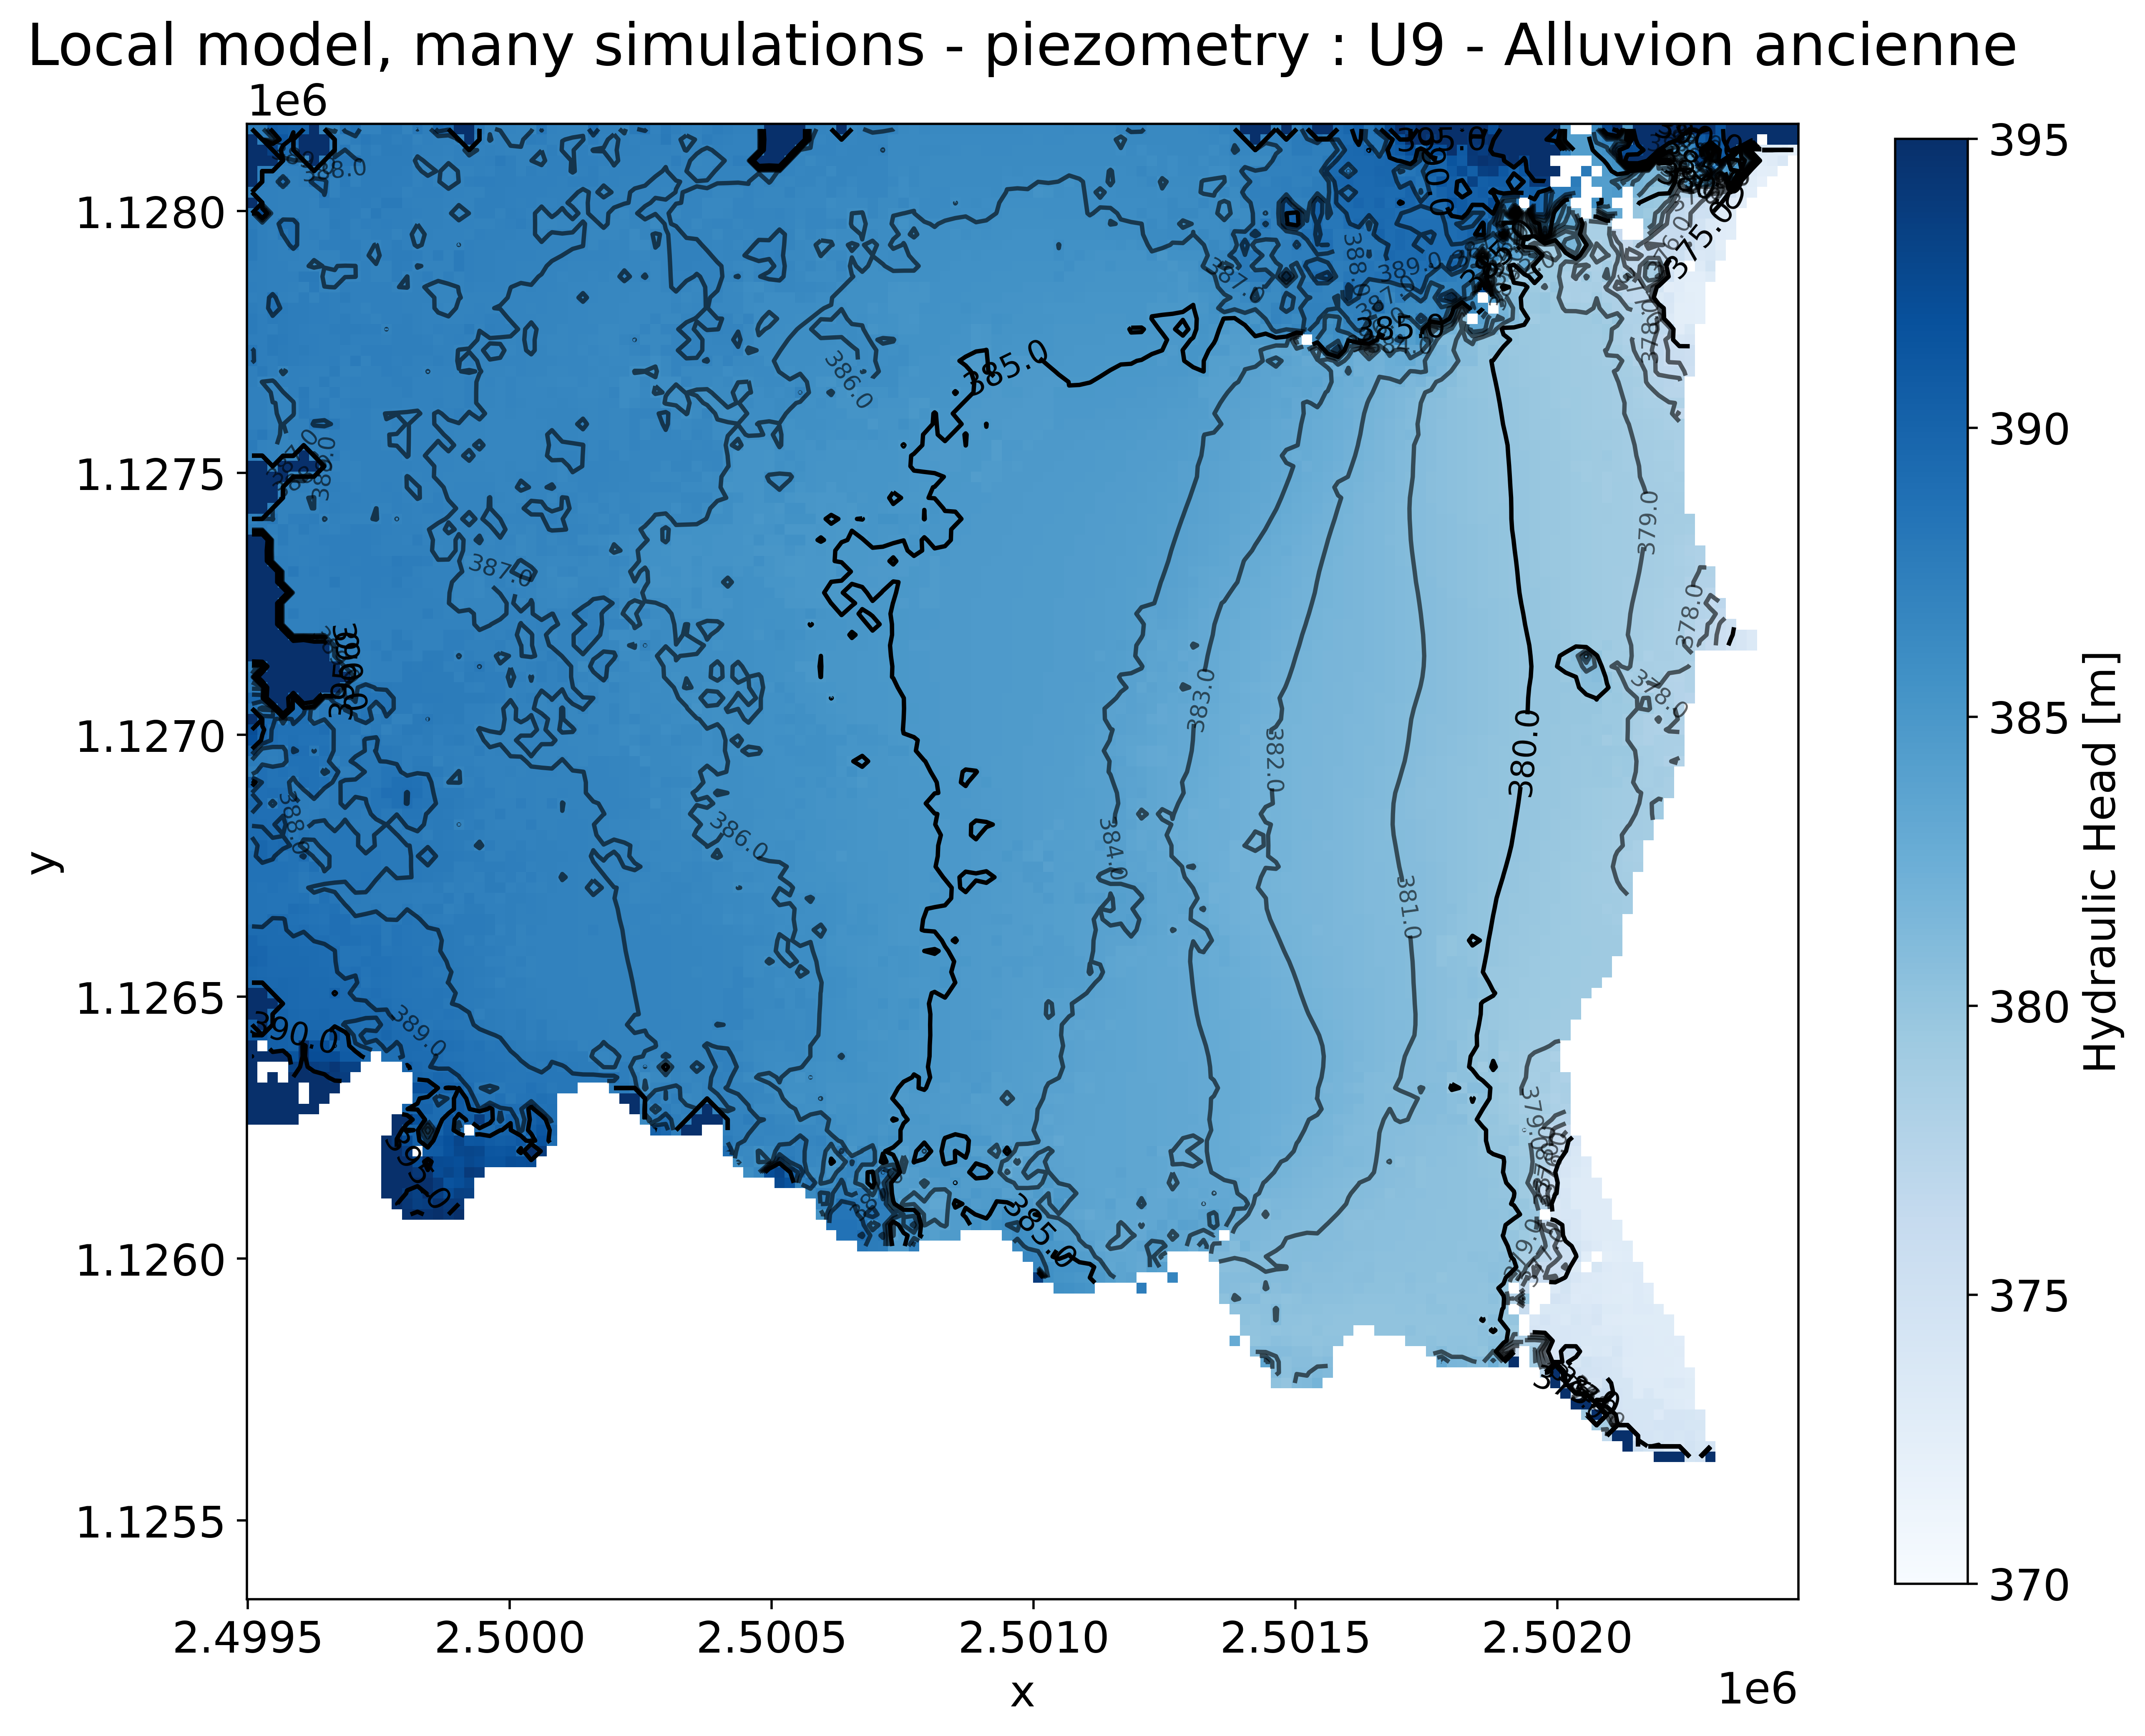

In [14]:
fig = plt.figure(figsize=(12, 12), dpi=500)
ax = fig.add_subplot(1, 1, 1, aspect="equal")
ax.set_title("Local model, many simulations - piezometry : U9 - Alluvion ancienne")
#ax.set_title("Local model, many simulations - piezometry : U7 - Wurmian formation")
#ax.set_title("Local model, many simulations - piezometry : U3 - Recent deposits")
mapview = fp.plot.PlotMapView(model=gwf, layer=2)
pc = mapview.plot_array(head_mean, cmap="Blues", vmax=395, vmin=370)

# contouring the head array

#contour_set_10 = mapview.contour_array(heads, colors="k", levels=[370, 375,376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390], alpha=0.6)
contour_set_10 = mapview.contour_array(head_mean, colors="k", levels=[376, 377, 378, 379, 381, 382, 383, 384, 386, 387, 388, 389], alpha=0.6)
contour_set = mapview.contour_array(head_mean, colors="k", levels=[370, 375, 380, 385, 390, 395])
plt.clabel(contour_set, fmt="%.1f", colors="k", fontsize=11)
plt.clabel(contour_set_10, fmt="%.1f", colors="k", fontsize=8)
linecollection = mapview.plot_grid(lw=0.25, color="k", alpha=0)

#mapview.plot_bc("wel", color="red")
#mapview.plot_bc("riv", color="green")

cb = plt.colorbar(pc, shrink=0.75, ax=ax,label='Hydraulic Head [m]')
plt.xlabel('x')
plt.ylabel('y')
plt.plot()
plt.show()

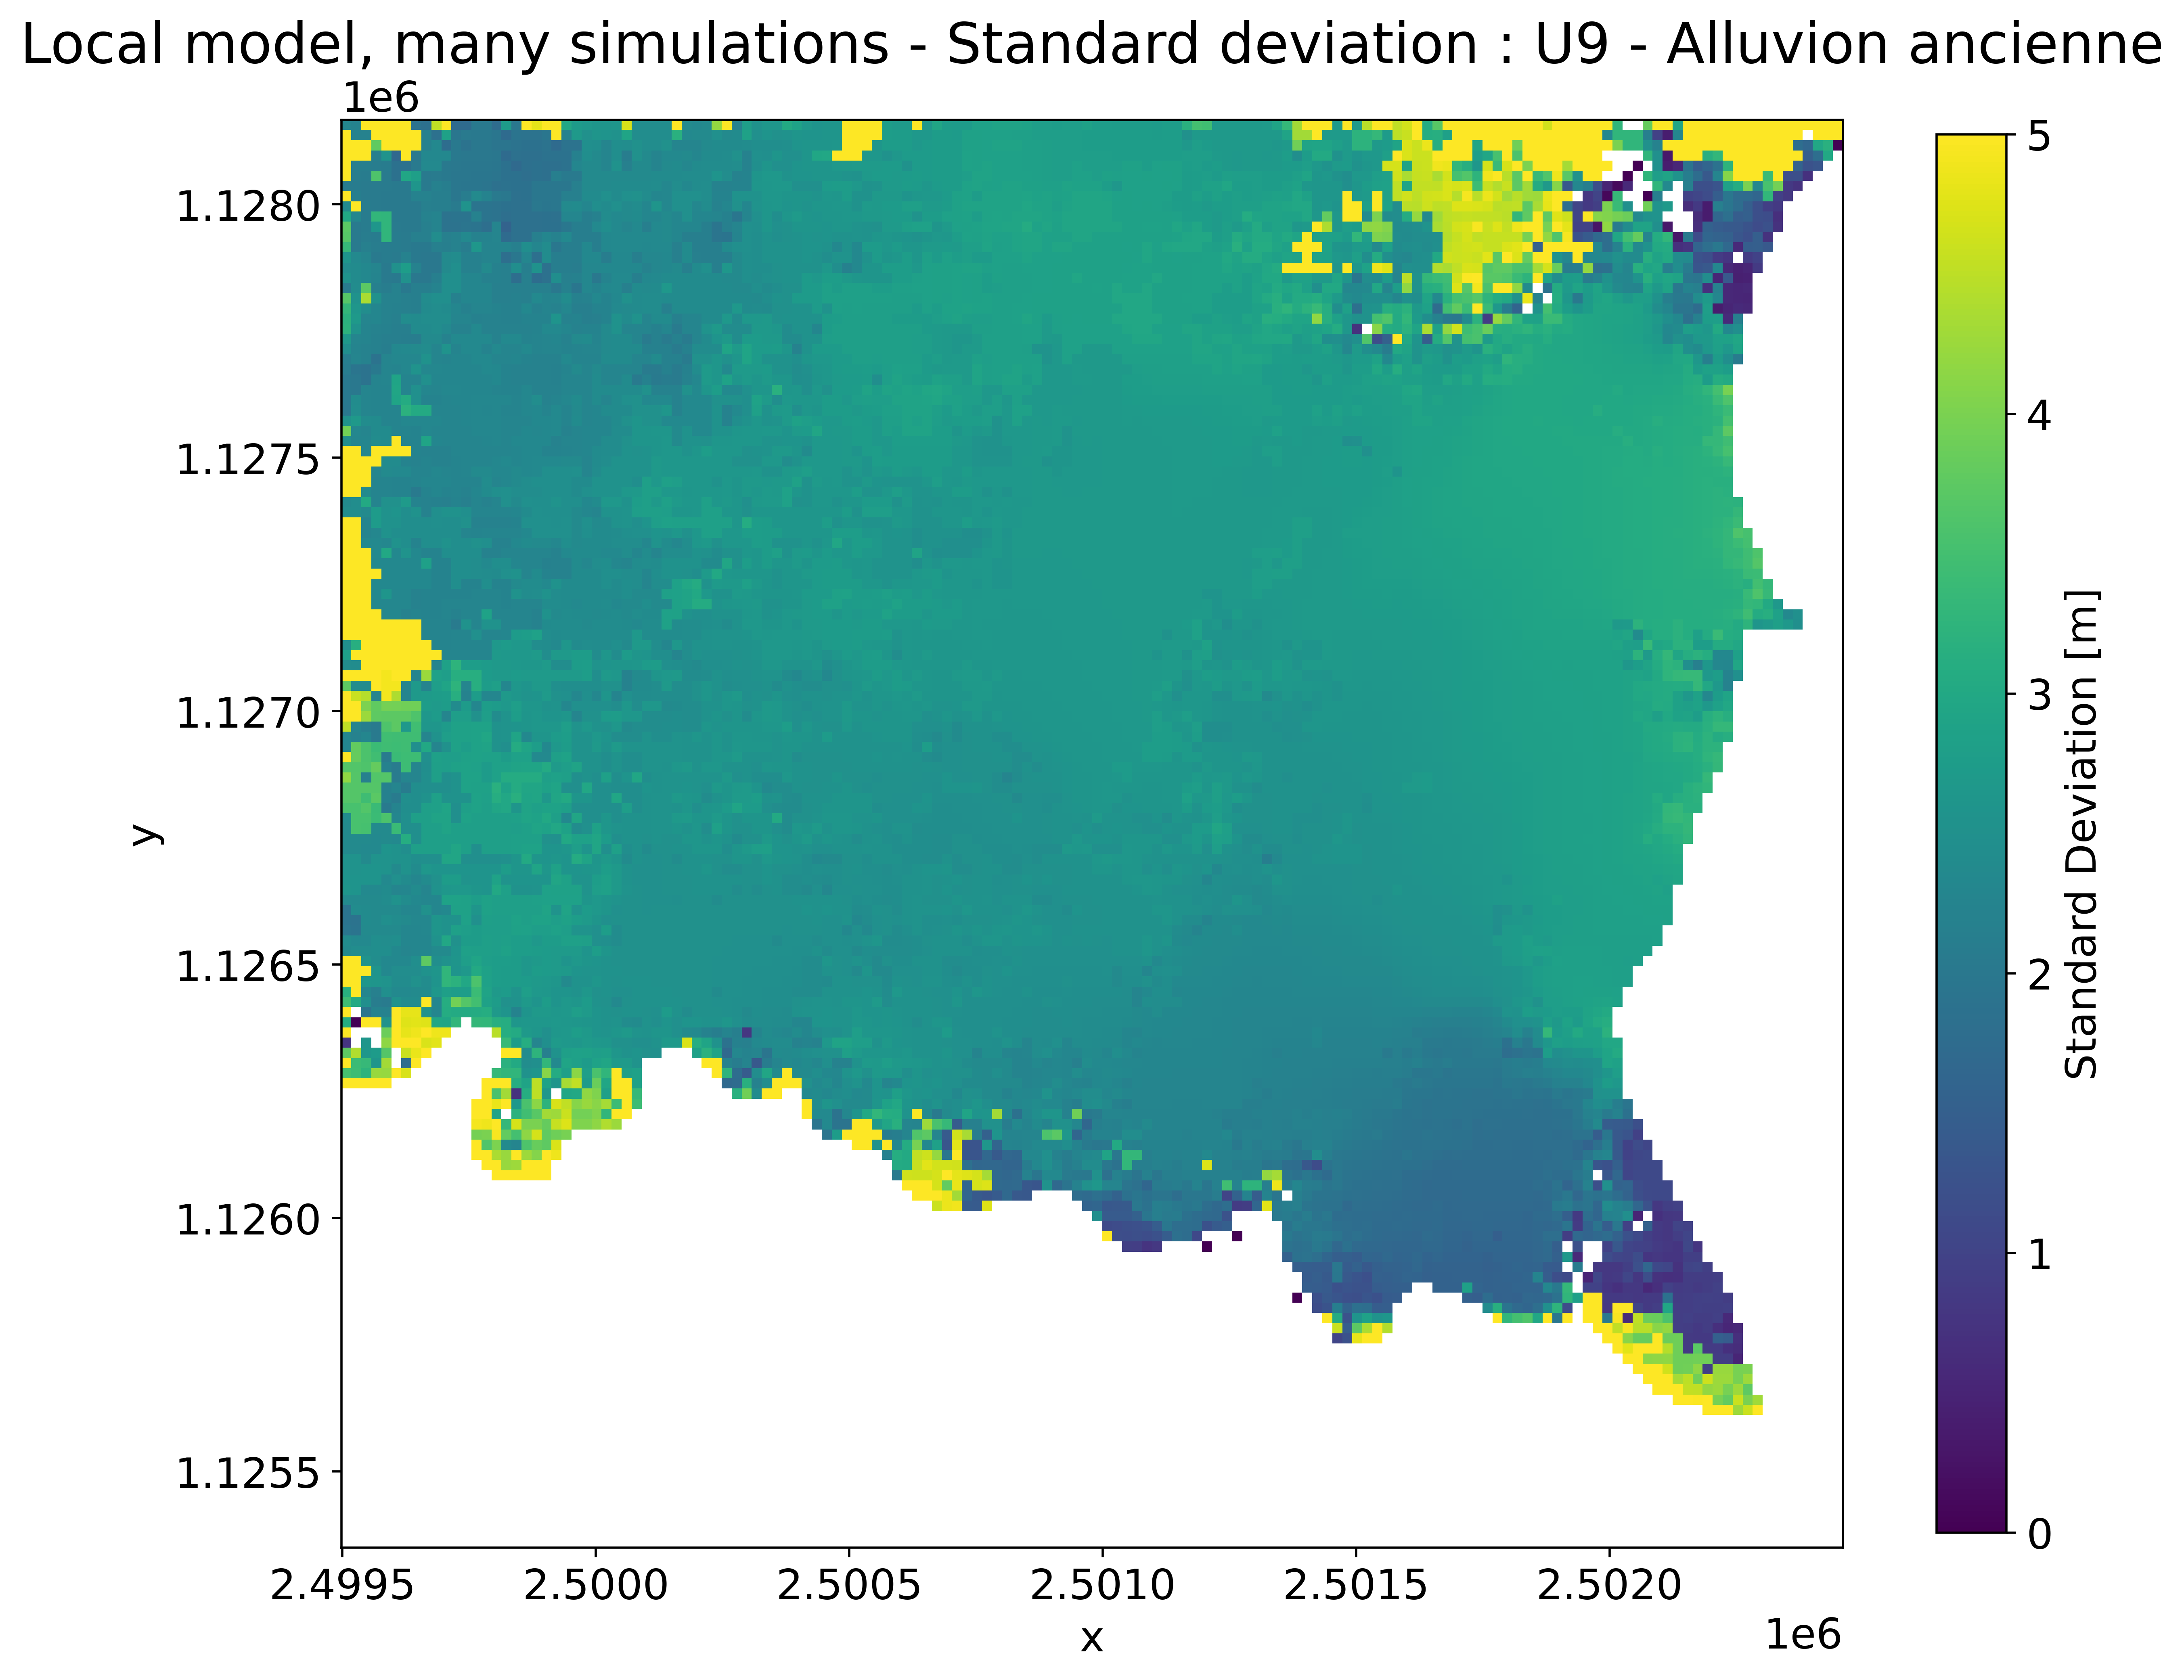

In [15]:
fig = plt.figure(figsize=(12, 12), dpi = 500)
ax = fig.add_subplot(1, 1, 1, aspect="equal")
ax.set_title("Local model, many simulations - Standard deviation : U9 - Alluvion ancienne")
#ax.set_title("Local model, many simulations - Standard deviation : U7 - Wurmian formation")
#ax.set_title("Local model, many simulations - Standard deviation : U3 - Recent deposits")
mapview = fp.plot.PlotMapView(model=gwf, layer=2)
pc = mapview.plot_array(head_std, cmap="viridis",vmax = 5)

linecollection = mapview.plot_grid(lw=0.25, color="k", alpha=0)

#mapview.plot_bc("wel", color="red")
#mapview.plot_bc("riv", color="green")

cb = plt.colorbar(pc, shrink=0.75, ax=ax,label='Standard Deviation [m]')
plt.xlabel('x')
plt.ylabel('y')
plt.plot()
plt.show()

In [16]:
#Observation heads
obs_data = np.loadtxt("data_folder_versoix_sector/obs_heads.csv", delimiter=';',skiprows=1)

In [17]:
x_obs = obs_data[:,0]
y_obs = obs_data[:,1]
h_obs = obs_data[:,2]

In [ ]:
fig = plt.figure(figsize=(12, 12), dpi=500)
ax = fig.add_subplot(1, 1, 1, aspect="equal")
ax.set_title("Local model, many simulations - piezometry : U9 - Alluvion ancienne")
#ax.set_title("Local model, many simulations - piezometry : U7 - Wurmian formation")
#ax.set_title("Local model, many simulations - piezometry : U3 - Recent deposits")
mapview = fp.plot.PlotMapView(model=gwf, layer=2)
pc = mapview.plot_array(head_mean, cmap="Blues", vmax=395, vmin=370)

# contouring the head array

#contour_set_10 = mapview.contour_array(heads, colors="k", levels=[370, 375,376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390], alpha=0.6)
contour_set_10 = mapview.contour_array(head_mean, colors="k", levels=[376, 377, 378, 379, 381, 382, 383, 384, 386, 387, 388, 389], alpha=0.6)
contour_set = mapview.contour_array(head_mean, colors="k", levels=[370, 375, 380, 385, 390, 395])
plt.clabel(contour_set, fmt="%.1f", colors="k", fontsize=11)
plt.clabel(contour_set_10, fmt="%.1f", colors="k", fontsize=8)
linecollection = mapview.plot_grid(lw=0.25, color="k", alpha=0)

#mapview.plot_bc("wel", color="red")
#mapview.plot_bc("riv", color="green")
plt.scatter(x=x_obs, y=y_obs, s=h_obs/10, c='red', marker='.', label='Observed Hydraulic Heads - measured on August 31 2020')
for i in range(len(x_obs)):
    plt.text(x_obs[i], y_obs[i], str(h_obs[i]), size=10)
#plt.colorbar(label='Charge observée le 31 aout 2020 [m]')

cb = plt.colorbar(pc, shrink=0.75, ax=ax,label='Hydraulic Head [m]')
plt.xlabel('x')
plt.ylabel('y')
plt.plot()
plt.show()

In [18]:
x_data = np.zeros((150, 140))
y_data = np.zeros((150, 140))

x_lenght = X1 - X0
y_lenght = Y1 - Y0

x_space = np.linspace(X0, X1, num=150)
y_space = np.linspace(Y0, Y1, num=140)

for ix in range(len(x_space)):    
    for iy in range(len(y_space)):
        x_data[ix, iy] = x_space[ix]
        y_data[ix, iy] = y_space[iy]

In [19]:
head_list[0].shape

(5, 140, 150)

In [102]:
len(h_obs)

22

In [104]:
h_sims = []
x_sim = []
y_sim = []

for i_obs in range(len(h_obs)):
    x_obs_pt = x_obs[i_obs]
    y_obs_pt = y_obs[i_obs]
    h_obs_pt = h_obs[i_obs]
    h_sim = []
    
    for heads in head_list:
        AA_head = heads[2]
        
   
        for xi in range(150-1):
            for yi in range(140-1):
                if x_data[xi, yi] <= x_obs_pt and y_data[xi, yi] <= y_obs_pt and x_data[xi+1, yi] > x_obs_pt and y_data[xi, yi+1] > y_obs_pt:
                    x_sim.append(x_data[xi, yi])
                    y_sim.append(y_data[xi, yi])
                    if AA_head[yi, xi] == AA_head[yi, xi] :#check that is not nan 
                        h_sim.append(AA_head[yi, xi])
                    else:
                        h_sim.append(np.nan)
                    break
    h_sims.append(h_sim)

In [115]:
x_sim_r = np.reshape(x_sim,(22,48))

In [119]:
x_sims = np.mean(x_sim_r,axis=1)

In [22]:
np.array(h_sims).shape

(22, 48)

In [23]:

for i in range(len(h_sims)):
    for j in range(len(h_sims[0])):
        if h_sims[i][j] != h_sims[i][j] :
            h_sims[i][j] = np.nanmean(h_sims[i], axis=0)

In [24]:
h_sims_md = np.nanmedian(h_sims, axis = 1)
h_sims_m = np.nanmean(h_sims, axis = 1)

In [25]:
np.array(h_sims).shape

(22, 48)

In [26]:
h_sims_m.shape

(22,)

In [27]:
plt.rc('font', size=15) #controls default text size
plt.rc('axes', titlesize=20) #fontsize of the title
plt.rc('axes', labelsize=15) #fontsize of the x and y labels
plt.rc('xtick', labelsize=15) #fontsize of the x tick labels
plt.rc('ytick', labelsize=15) #fontsize of the y tick labels
plt.rc('legend', fontsize=15) #fontsize of the legend

In [28]:
h_obs_2 = []

for i in range(len(h_obs)):
    if i == 10 or 1 == 20 :
        a = 1
    else:
        h_obs_2.append(h_obs[i])

In [29]:
h_obs_nan = np.insert(h_obs, 0, np.nan)

In [30]:
np.array(h_sims).shape

(22, 48)

In [31]:
h_sims_mean = np.nanmean(h_sims,axis=0).shape

In [32]:
h_sims_mean

(48,)

In [59]:
h_sims_mn = h_sims_m

In [63]:
h_sims_mn = np.append(h_sims_mn, np.nan)

In [64]:
len(h_sims_mn)

23

In [86]:
addon = np.zeros(48)
for i in range(len(addon)):
    addon[i] = np.nan

In [88]:
h_sims.append(addon)

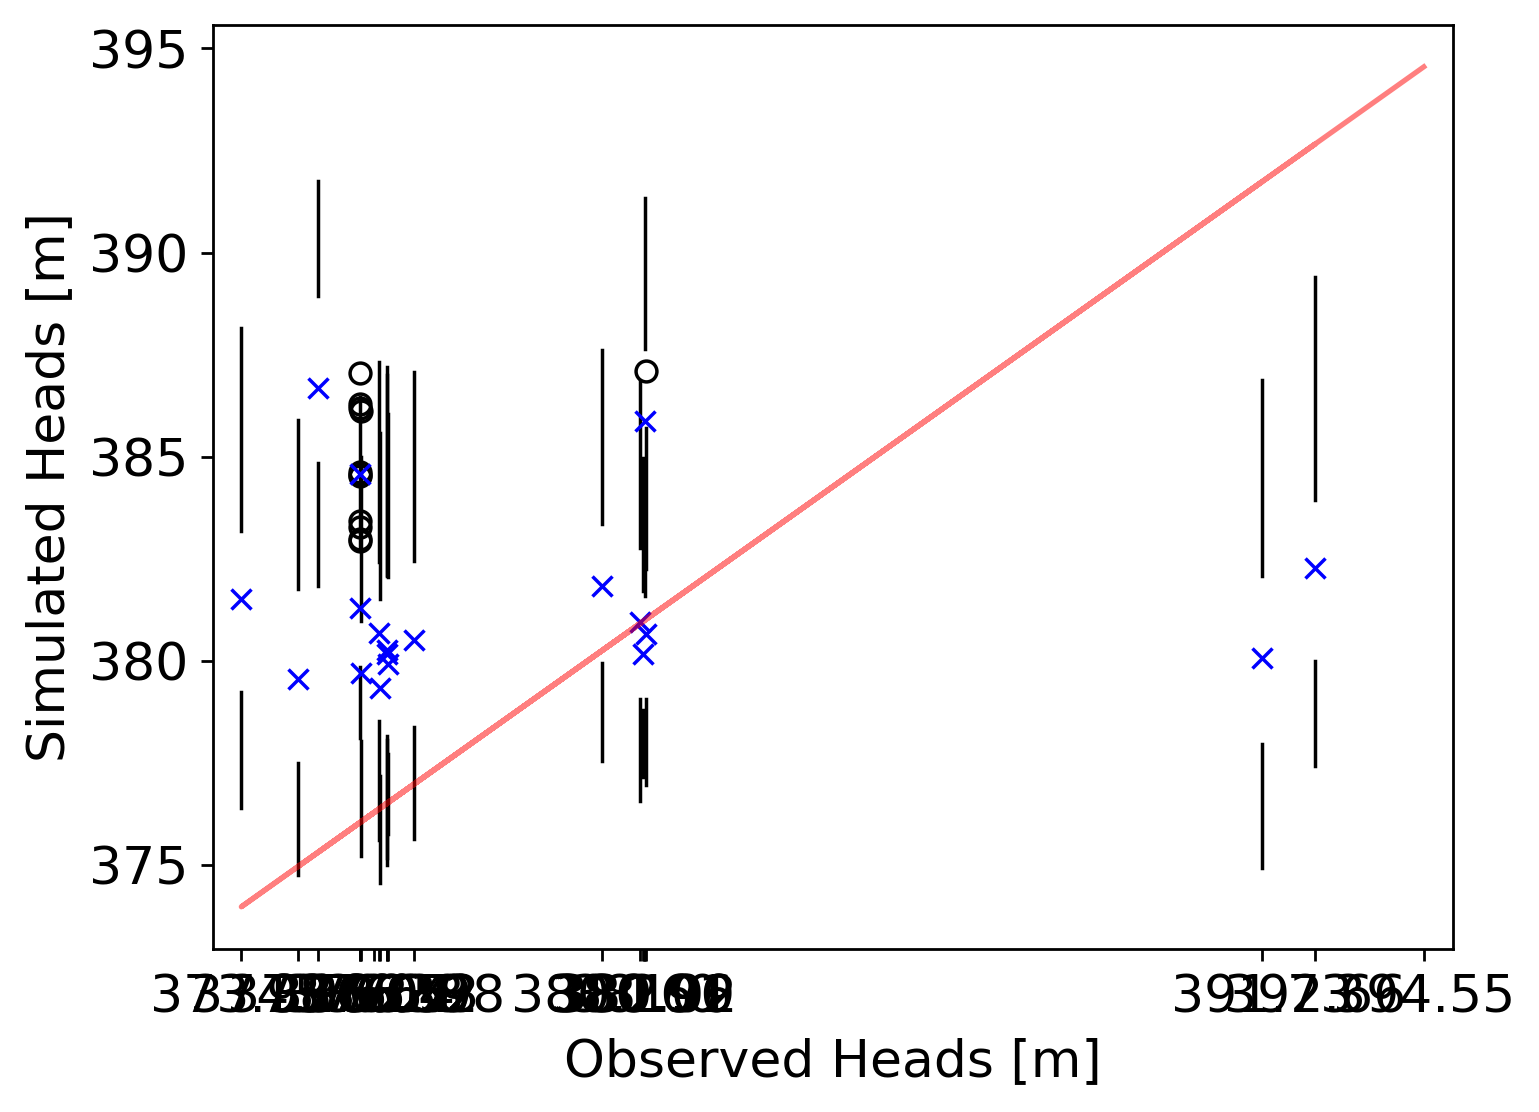

In [95]:
plt.figure(dpi=250)
#plt.plot(, h_sims_m, 'x', color='b', label='Simulated heads')
plt.boxplot(h_sims,positions=h_obs_nan, showbox=False, showcaps=False)
plt.plot(h_obs_nan,h_sims_mn, 'x', color='b')
#plt.legend()
plt.plot(h_obs_nan,h_obs_nan, '-', color='r', alpha=0.5)
plt.xlabel('Observed Heads [m]')
plt.ylabel('Simulated Heads [m]')
plt.show()

In [36]:
medianprops = dict(linestyle='-', linewidth=1, color='b')

In [37]:
plt.rc('font', size=20) #controls default text size
plt.rc('axes', titlesize=25) #fontsize of the title
plt.rc('axes', labelsize=29) #fontsize of the x and y labels
plt.rc('xtick', labelsize=20) #fontsize of the x tick labels
plt.rc('ytick', labelsize=20) #fontsize of the y tick labels
plt.rc('legend', fontsize=20) #fontsize of the legend

In [150]:
h_sims_nd = np.array(h_sims)
mask = ~np.isnan(h_sims_nd)
#filtered_h_sims = [d[m] for d, m in zip(h_sims_nd.T, mask.T)]
filtered_h_sims = [d[m] for d, m in zip(h_sims_nd, mask)]

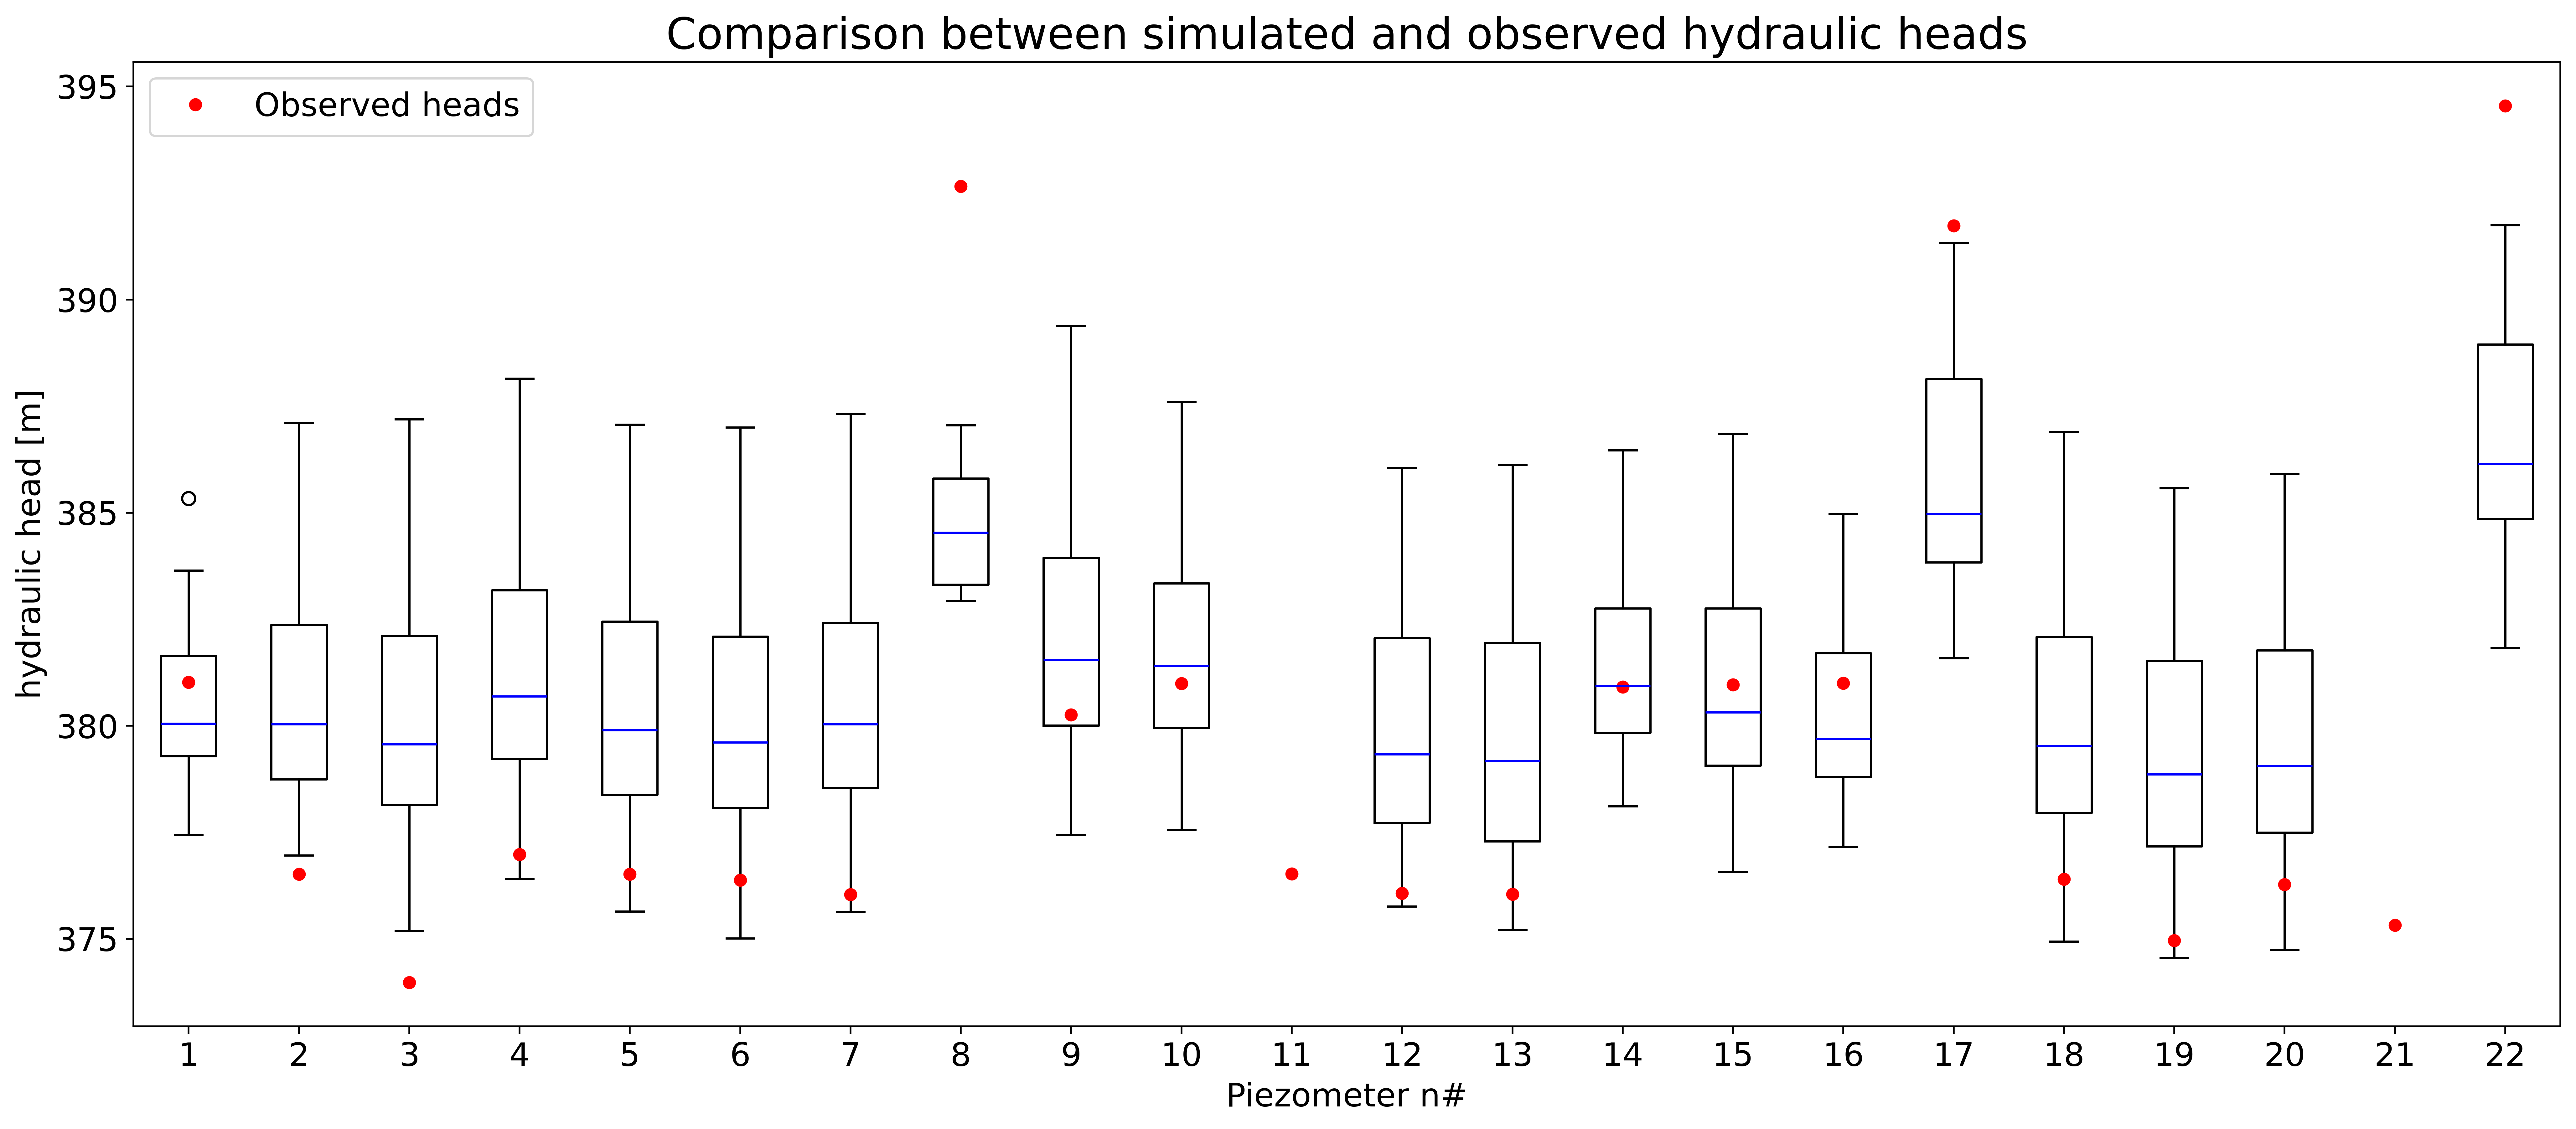

In [151]:
fig = plt.figure(figsize=(20, 8), dpi=500)
plt.boxplot(filtered_h_sims, medianprops=medianprops)
plt.plot(h_obs_nan, '.', color='r', label='Observed heads', markersize=10)
#plt.plot(h_sims_md, 'x', color='r', label='Median of the simulated heads')
#plt.plot(h_sims_m, '.', color='r', label='Mean of the simulated heads')
plt.title('Comparison between simulated and observed hydraulic heads', fontsize=20)
plt.xlabel('Piezometer n#', fontsize=15)
plt.ylabel('hydraulic head [m]', fontsize=15)
plt.legend()
plt.show()

In [40]:
name_obs = []
for i in range(len(h_obs)):
    name_obs.append(str(i+1))

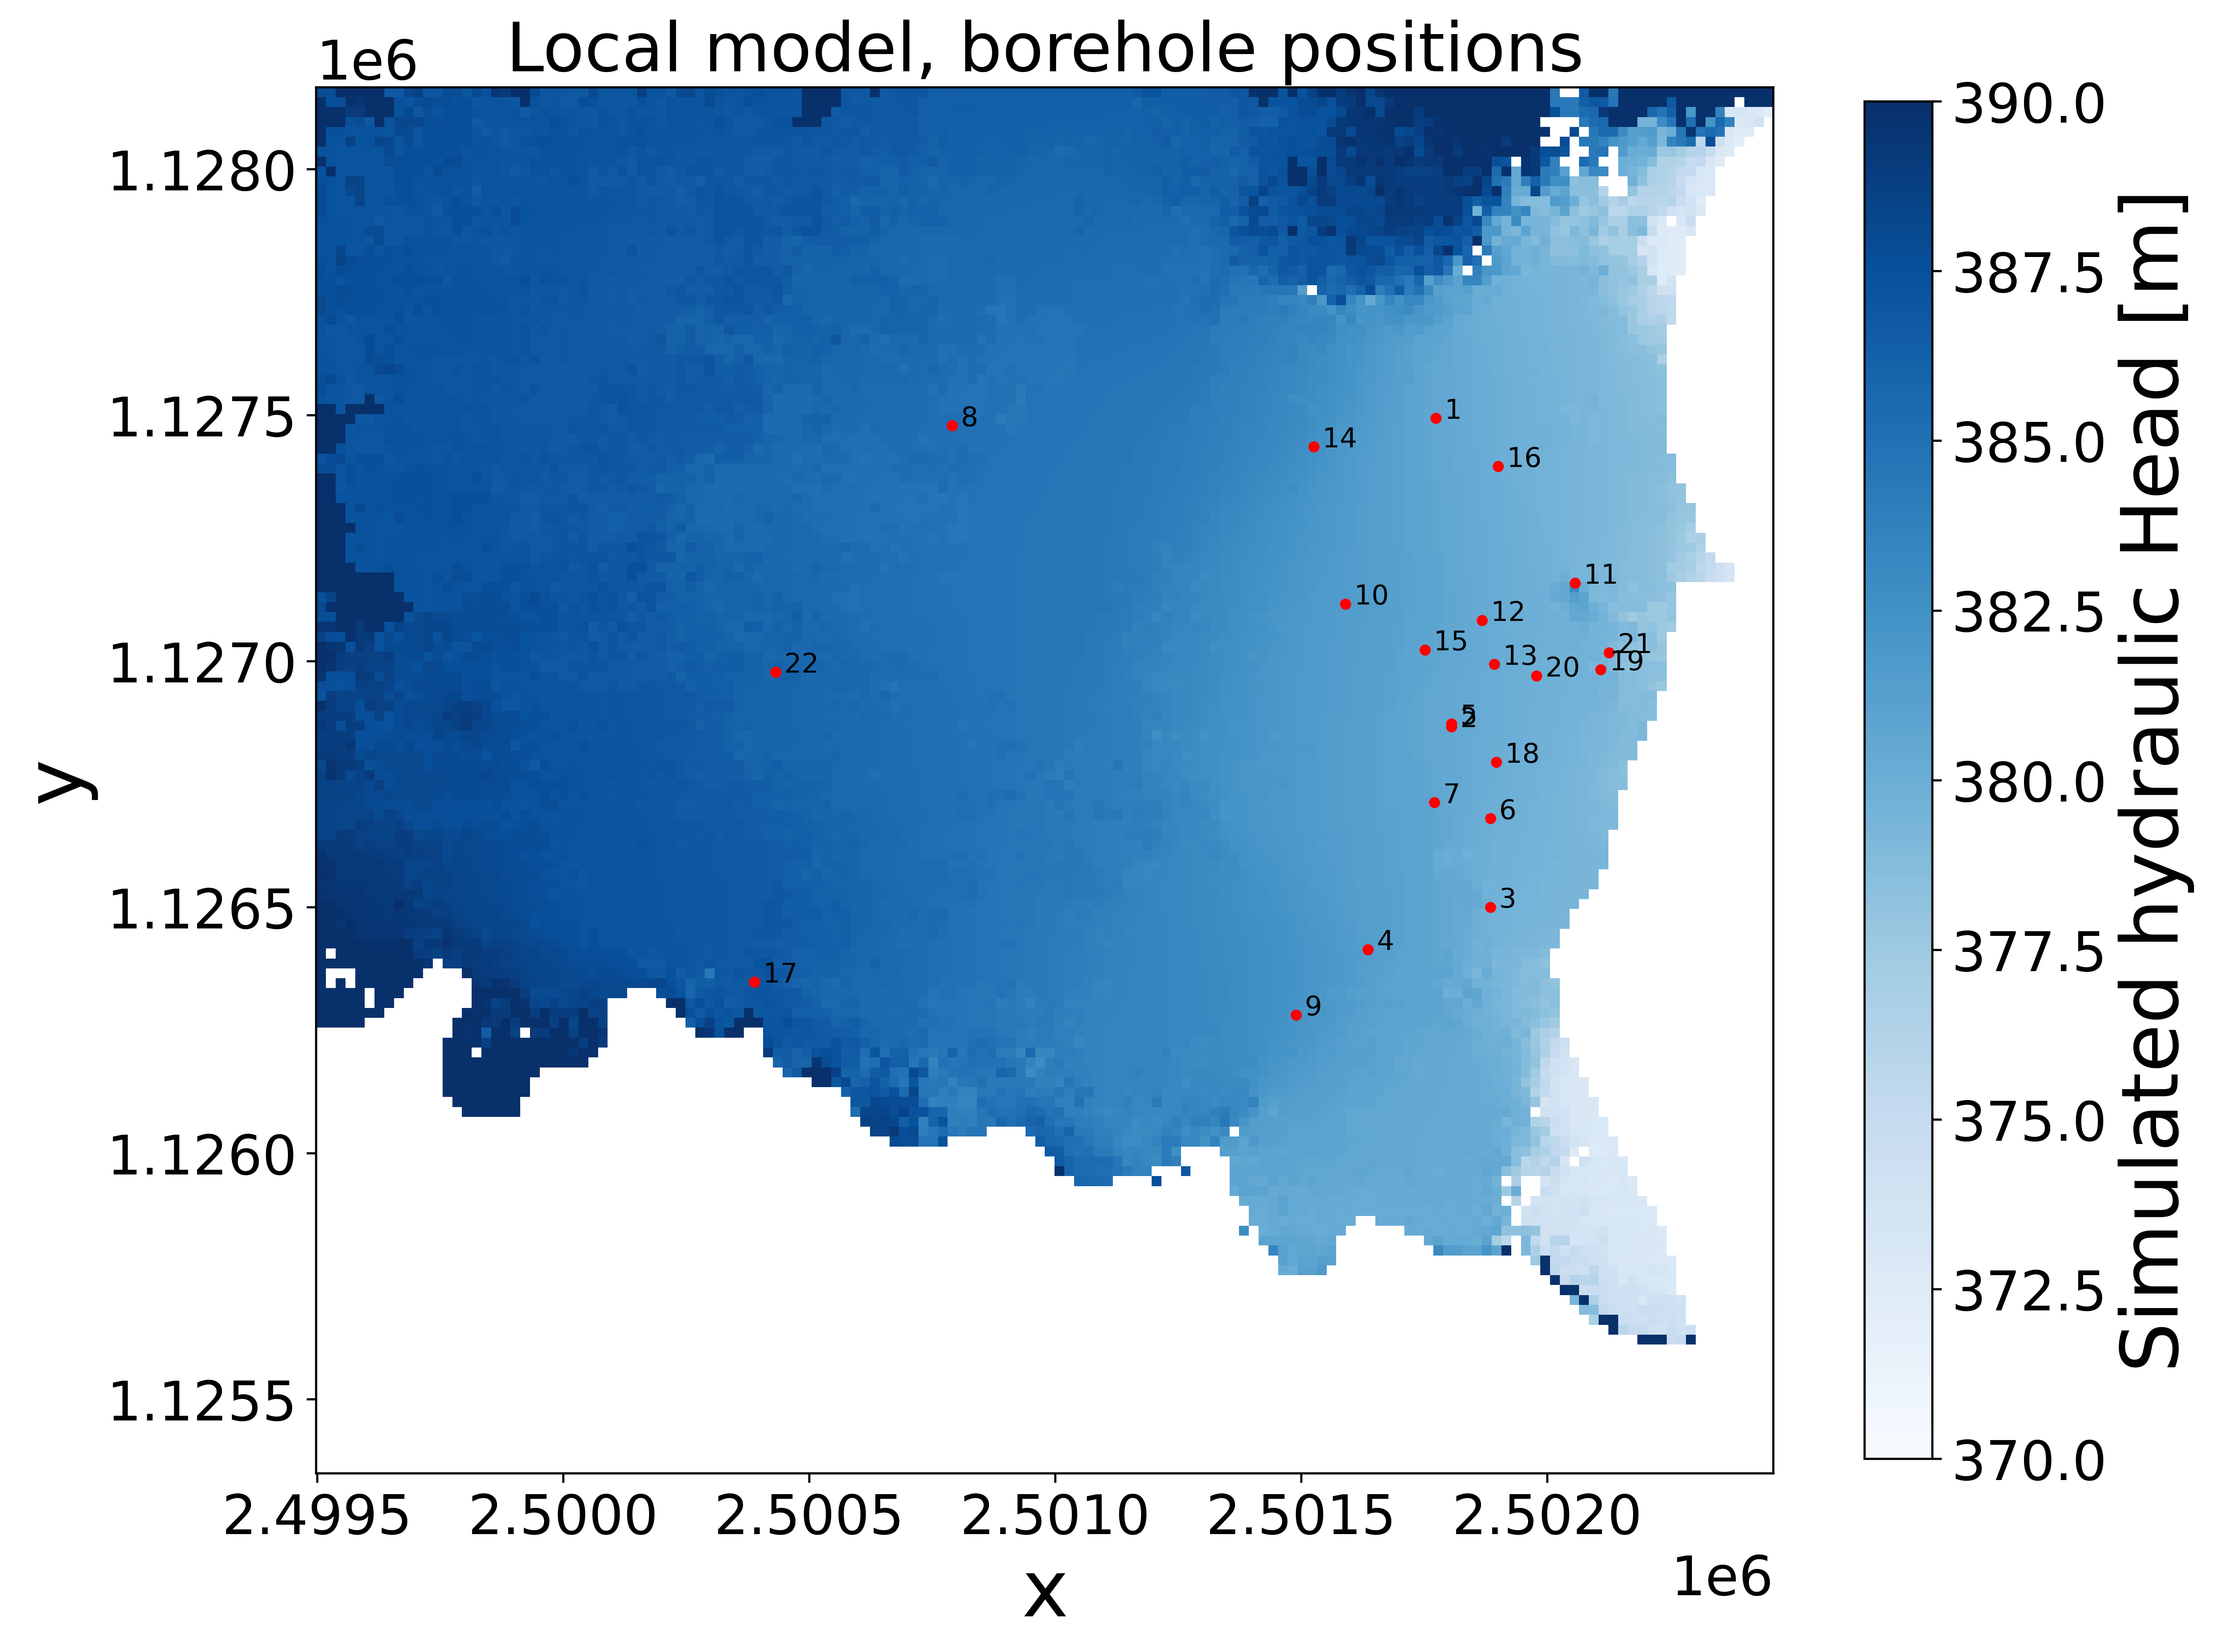

In [41]:
fig = plt.figure(figsize=(12, 12), dpi=500)
ax = fig.add_subplot(1, 1, 1, aspect="equal")
ax.set_title("Local model, borehole positions")
#ax.set_title("Local model, many simulations - piezometry : U7 - Wurmian formation")
#ax.set_title("Local model, many simulations - piezometry : U3 - Recent deposits")
mapview = fp.plot.PlotMapView(model=gwf, layer=2)
pc = mapview.plot_array(head_mean, cmap="Blues", vmax=390, vmin=370)

plt.scatter(x=x_obs, y=y_obs, s=h_obs/10, c='red', marker='.')
for i in range(len(x_obs)):
    plt.text(x_obs[i], y_obs[i], str(' '+name_obs[i]), size=10)


cb = plt.colorbar(pc, shrink=0.75, ax=ax,label='Simulated hydraulic Head [m]')
plt.xlabel('x')
plt.ylabel('y')
plt.plot()
plt.show()

In [42]:
def replace_nans(arr, fill_value=-9999.0):
    arr_fixed = np.copy(arr)
    arr_fixed[np.isnan(arr_fixed)] = fill_value
    return arr_fixed

In [43]:
from sklearn.metrics import mean_squared_error
from math import sqrt


In [44]:
h_sims_n = replace_nans(h_sims_m, 0)

In [45]:
sqrt(mean_squared_error(h_obs, h_sims_n)) 

113.41951343574526

In [46]:
np.array(h_sims).shape

(22, 48)

In [47]:
np.array(h_sims)[:,0].shape

(22,)

In [48]:
h_obs_r = []
h_sims_r = []
for i in range(22):
    if i != 10 and i != 20 :
        h_obs_r.append(h_obs[i])
        h_sims_r.append(h_sims[i])

In [49]:
RMSE_list = []

for i_sim in range(48):
    sim = np.array(h_sims_r)[:,i_sim]
    RMSE_list.append(sqrt(mean_squared_error(h_obs_r, sim)))

In [50]:
plt.rc('font', size=15) #controls default text size
plt.rc('axes', titlesize=17) #fontsize of the title
plt.rc('axes', labelsize=15) #fontsize of the x and y labels
plt.rc('xtick', labelsize=15) #fontsize of the x tick labels
plt.rc('ytick', labelsize=15) #fontsize of the y tick labels
plt.rc('legend', fontsize=15) #fontsize of the legend

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

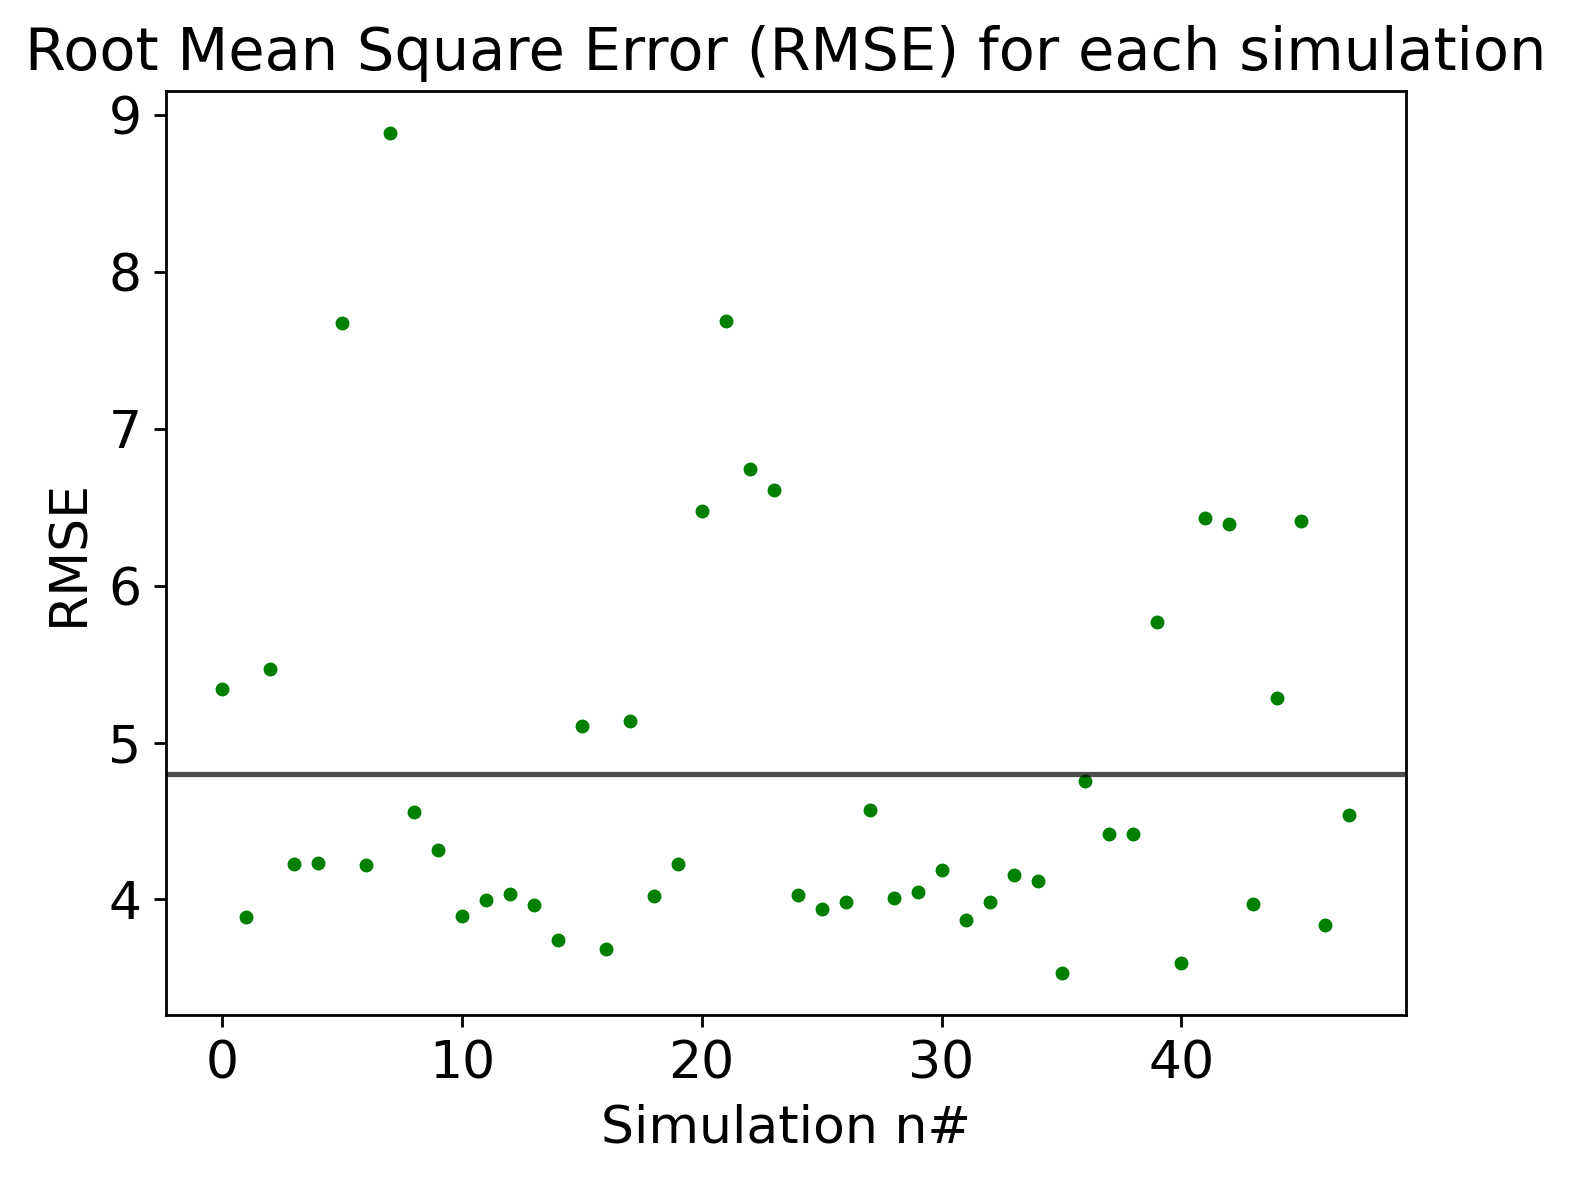

In [51]:
plt.figure(dpi=250)
plt.plot(RMSE_list, '.', color='g')
plt.axhline(y=np.mean(RMSE_list), color='k', linestyle='-', alpha=0.7)
plt.xlabel('Simulation n#')
plt.ylabel('RMSE')
plt.title('Root Mean Square Error (RMSE) for each simulation')
plt.plot

In [52]:
np.mean(RMSE_list)

4.800179813355812